In [1]:
import pandas as pd
df = pd.read_csv('data/9000plus.csv')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [8]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [3]:
df = df.drop_duplicates()
df.shape

(9837, 9)

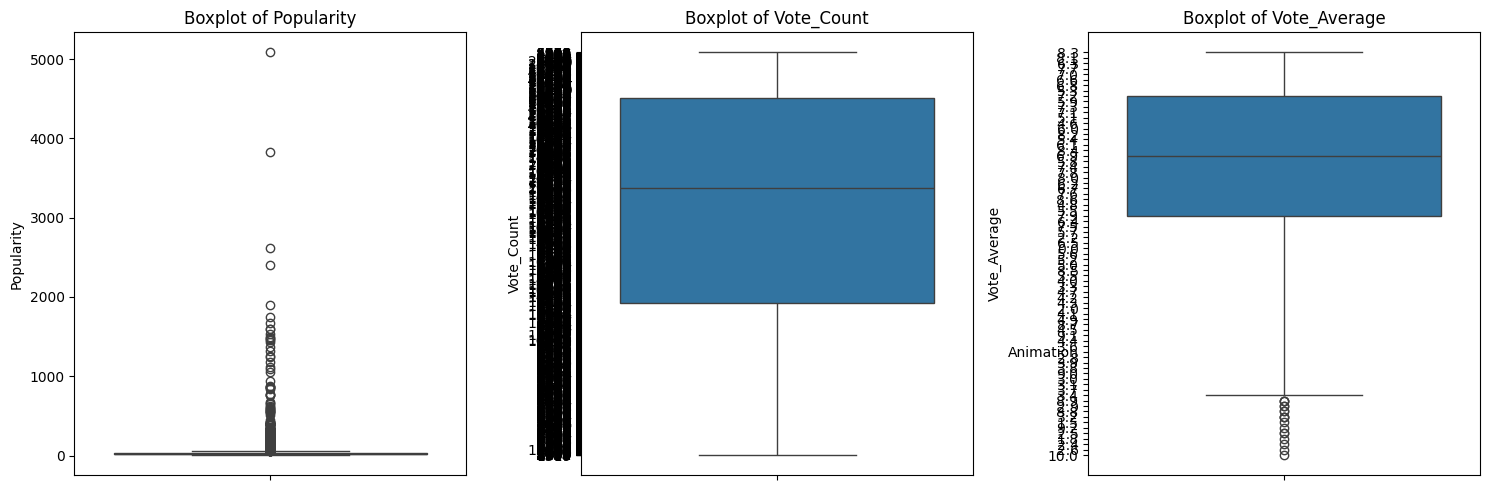

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_cols = ['Popularity', 'Vote_Count', 'Vote_Average']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [7]:
df = df.dropna()
df.shape

(9826, 9)

In [13]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df.dtypes

Release_Date         datetime64[ns]
Title                        object
Overview                     object
Popularity                  float64
Vote_Count                    int64
Vote_Average                float64
Original_Language            object
Genre                        object
Poster_Url                   object
dtype: object

In [14]:
invalid_vote_count = df[df['Vote_Count'] < 0]
invalid_popularity = df[df['Popularity'] < 0]
invalid_vote_average = df[(df['Vote_Average'] < 0) | (df['Vote_Average'] > 10)]
print('Invalid Vote_Count:', len(invalid_vote_count))
print('Invalid Popularity:', len(invalid_popularity))
print('Invalid Vote_Average:', len(invalid_vote_average))

Invalid Vote_Count: 0
Invalid Popularity: 0
Invalid Vote_Average: 0


In [17]:
import requests
def check_url(url):
    try:
        response = requests.head(url, timeout=3)
        return response.status_code == 200
    except Exception:
        return False
url_checks = df['Poster_Url'].apply(check_url)
url_checks

0       True
1       True
2       True
3       True
4       True
        ... 
9832    True
9833    True
9834    True
9835    True
9836    True
Name: Poster_Url, Length: 9826, dtype: bool

In [ ]:
import os
import requests
from tqdm import tqdm
os.makedirs('posters', exist_ok=True)
for idx, row in tqdm(df.iterrows(), total=len(df)):
    url = row['Poster_Url']
    title = str(row['Title']).replace('/', '_').replace('\\', '_').replace(' ', '_')  # Clean filename
    filename = f"posters/{title}.jpg"
    
    try:
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
    except Exception as e:
        print(f"Failed to download {url}: {e}")